#   Ανάλυση Βιο-δεδομένων

#  Synthetic Medical Data Generation: Opportunities and Challenges for GenAI-Based Augmentation

Βάση Δεδομένων: Diabetes Health Indicators Dataset

https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset



Μέλη Ομάδας:

- 03400305 - Παντελεήμων Ναούμ
- 03400288 - Ανδρέας Γκανάς
- 03400289 - Κερκύρα Δημησίανου

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as ms

##  Exploratory Data Analysis (EDA)

Αρχικά πραγματοποιείται import των δεδομένων και EDA. 

Θα χρησιμοποιηθεί το dataset από το αρχείο diabetes_012_health_indicators_BRFSS2015.csv. <br>
Η στήλη Diabetes_012 δείχνει την κλάση και δέχεται τιμές:

- 0: όχι διαβήτης
- 1: προ-διαβήτης
- 2: διαβήτης

In [2]:
filepath = "dataset/cleaned/diabetes_012_health_indicators_BRFSS2015.csv"
data = pd.read_csv(filepath, sep=',')

Παρακάτω φαίνονται τα πρώτα 5 rows του dataset. Όλες οι στήλες έχουν αριθμητικές τιμές.

In [3]:
pd.set_option('display.max_columns', None)
data.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


Το dataset περιέχει τα ακόλουθα features:
- Diabetes_012:             Η κλάση
- HighBP:                   0 = no high BP 1 = high BP
- HighChol:                 0 = no high cholesterol 1 = high cholesterol
- CholCheck:                0 = no cholesterol check in 5 years, 1 = yes cholesterol check in 5 years
- BMI:                      Body Mass Index
- Smoker:                   Have you smoked at least 100 cigarettes in your entire life? [Note: 5 packs = 100 cigarettes] 0 = no 1 = yes
- Stroke:                   (Ever told) you had a stroke. 0 = no 1 = yes
- HeartDiseaseorAttack:     coronary heart disease (CHD) or myocardial infarction (MI) 0 = no 1 = yes
- PhysActivity:             physical activity in past 30 days - not including job 0 = no 1 = yes
- Fruits:                   Consume Fruit 1 or more times per day 0 = no 1 = yes
- Veggies:                  Consume Vegetables 1 or more times per day 0 = no 1 = yes
- HvyAlcoholConsump:        Heavy drinkers (adult men having more than 14 drinks per week and adult women having more than 7 drinks per week) <br> 0 = no 1 = yes    

- AnyHealthcare:            Have any kind of health care coverage, including health insurance, prepaid plans such as HMO, etc. 0 = no 1 = yes
- NoDocbcCost:              Was there a time in the past 12 months when you needed to see a doctor but could not because of cost? 0 = no 1 = yes
- GenHlth:                  Would you say that in general your health is: scale 1-5 1 = excellent, 2 = very good, 3 = good, 4 = fair, 5 = poor
- MentHlth:                 Now thinking about your mental health, which includes stress, depression, and problems with emotions, for how many days during the past 30 days was your mental health not good? scale 1-30 days

- PhysHlth:                 Now thinking about your physical health, which includes physical illness and injury, for how many days during the past 30 days was your physical health not good? scale 1-30 days

- DiffWalk:                 Do you have serious difficulty walking or climbing stairs? 0 = no 1 = yes
- Sex:                      0 = female 1 = male
- Age:                      13-level age category (_AGEG5YR see codebook) 1 = 18-24 9 = 60-64 13 = 80 or older

- Education:                Education level (EDUCA see codebook) scale 1-6 1 = Never attended school or only kindergarten 2 = Grades 1 through 8 (Elementary) 3 = Grades 9 through 11 (Some high school) 4 = Grade 12 or GED (High school graduate) 5 = College 1 year to 3 years (Some college or technical school) 6 = College 4 years or more (College graduate)

- Income:                   Income scale (INCOME2 see codebook) scale 1-8 1 = less than $10,000 5 = less than $35,000 8 = $75,000 or more

Κοιτώντας το είδος από κάθε feature, βλέπουμε πως όλες οι στήλες έχουν Dtype float64. 

Επιπλέον, όλα έχουν 253680 non-null value. Εφόσον ο συνολικός αριθμός γραμμών είναι 253680, συμπεραίνεται πως δεν υπάρχουν empty cells στο dataset.<br> 
Αυτό είναι αναμενόμενο καθώς ήταν ήδη cleaned.

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

<Axes: >

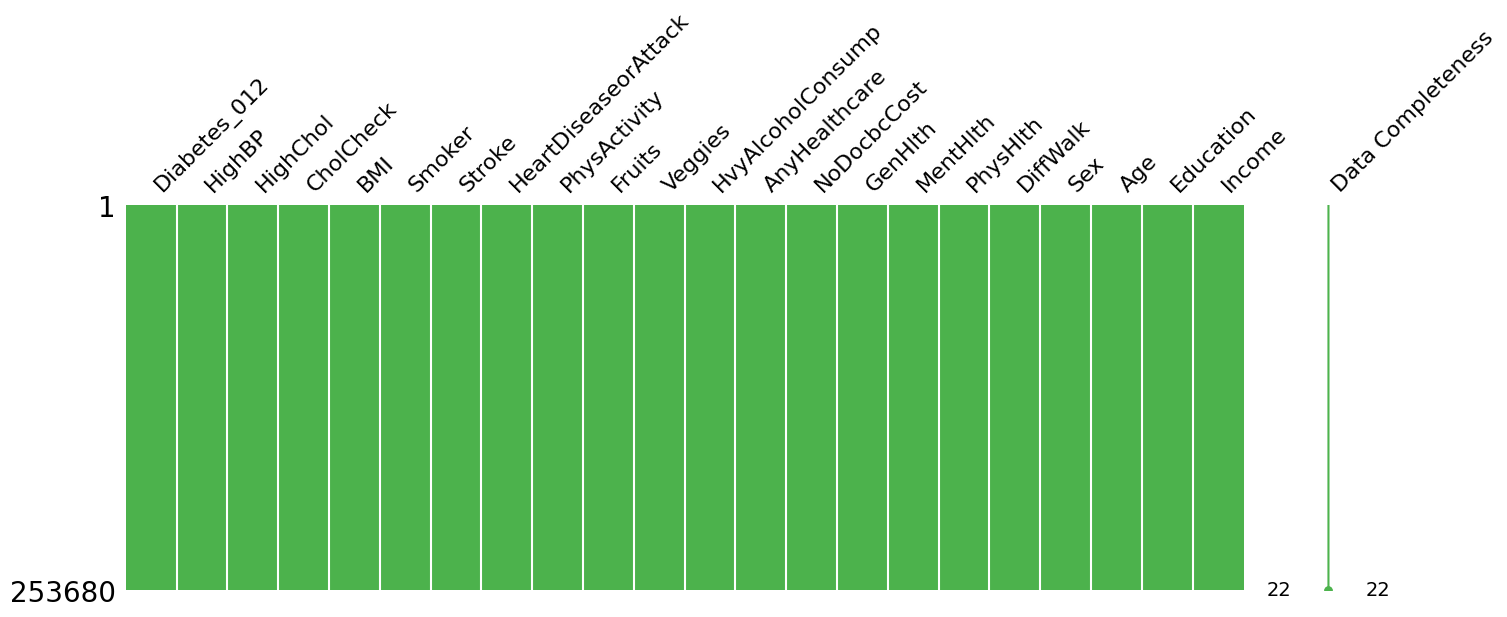

In [5]:
ms.matrix(data, figsize=(16, 5), color = (0.3, 0.7, 0.3), labels=True)

Παρακάτω βλέπουμε σε Horizontal bar chart πόσοι patients ανήκουν σε κάθε κλάση. Τα δεδομένα είναι unbalanced.

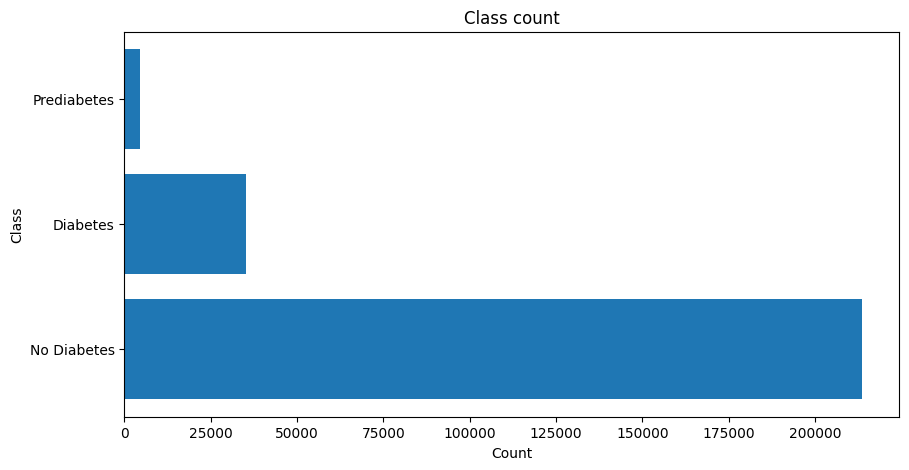

In [6]:
def show_class_inbalance(data, title='Class count'):
    mapping = {
        0: "No Diabetes",
        1: "Prediabetes",
        2: "Diabetes"
    }

    if isinstance(data, pd.DataFrame):
        series = data['Diabetes_012']
    else:
        series = data

    counts = series.map(mapping).value_counts()

    plt.figure(figsize=(10, 5))
    plt.barh(counts.index, counts.values)
    plt.ylabel("Class")
    plt.xlabel("Count")
    plt.title(title)
    plt.show()

show_class_inbalance(data)

Επίσης, εκτυπώνοντας στατιστικά για το dataset βλέπουμε για κάθε feature το mean, standard deviation, min, 25% percentatile, median, 75% percentile και max. 

- Από τα independent variables, τα features <b>ΒΜΙ, MentHealth</b> και <b>PhysHlth</b> είναι numeric. Επειδή εχουν διαφορετικές κλίμακες, θα χρειαστεί αργότερα να πραγματοποιήσουμε standardization.

- Οι μεταβλητές <b>GenHlth</b>, <b>Age</b>, <b>Education</b>, <b>Income</b> αποτελούν κατηγορηματικές μεταβλητές με πάνω από 2 κατηγορίες. Πιθανώς στην συνέχεια να χρειαστεί να δημιουργήσουμε dummy variables αν χρησιμοποιήσουμε κάποιο ταξινομητή όπως logistic regression.

- Οι υπόλοιπες μεταβλητές είναι binary categorical variables.

In [7]:
data.describe()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.296921,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,0.811420,0.056197,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.698160,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,0.391175,0.230302,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,2.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


Παρακάτω βλέπουμε ιστογράμματα για κάθε μεταβλητή. Παρατηρούμε πως:
- Ελάχιστα άτομα δεν έχουν ελέγξει την χολιστερίνη τα τελευταία 5 χρόνια.
- Ελάχιστα άτομα έχουν περάσει εγκεφαλικό επεισόδιο.
- Ελάχιστα άτομα έχουν coronary heart disease (CHD) ή myocardial infarction (MI)
- Λίγα άτομα δεν καταναλώνουν λαχανικά.
- Ελάχιστα άτομα καταναλώνουν πολύ αλκόολ.
- Ελάχιστα άτομα δεν έχουν κάληψη για την υγεία.
- Ελάχιστα άτομα δεν έχουν λεφτά για να πάνε στο γιατρό.
- Λίγα άτομα έχουν δυσκολία να περπατήσουν.

C:\Users\angan\AppData\Local\Temp\ipykernel_1840\3392517228.py:3: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  data.hist(ax = ax)


array([[<Axes: title={'center': 'Diabetes_012'}>,
        <Axes: title={'center': 'HighBP'}>,
        <Axes: title={'center': 'HighChol'}>,
        <Axes: title={'center': 'CholCheck'}>,
        <Axes: title={'center': 'BMI'}>],
       [<Axes: title={'center': 'Smoker'}>,
        <Axes: title={'center': 'Stroke'}>,
        <Axes: title={'center': 'HeartDiseaseorAttack'}>,
        <Axes: title={'center': 'PhysActivity'}>,
        <Axes: title={'center': 'Fruits'}>],
       [<Axes: title={'center': 'Veggies'}>,
        <Axes: title={'center': 'HvyAlcoholConsump'}>,
        <Axes: title={'center': 'AnyHealthcare'}>,
        <Axes: title={'center': 'NoDocbcCost'}>,
        <Axes: title={'center': 'GenHlth'}>],
       [<Axes: title={'center': 'MentHlth'}>,
        <Axes: title={'center': 'PhysHlth'}>,
        <Axes: title={'center': 'DiffWalk'}>,
        <Axes: title={'center': 'Sex'}>, <Axes: title={'center': 'Age'}>],
       [<Axes: title={'center': 'Education'}>,
        <Axes: title={'c

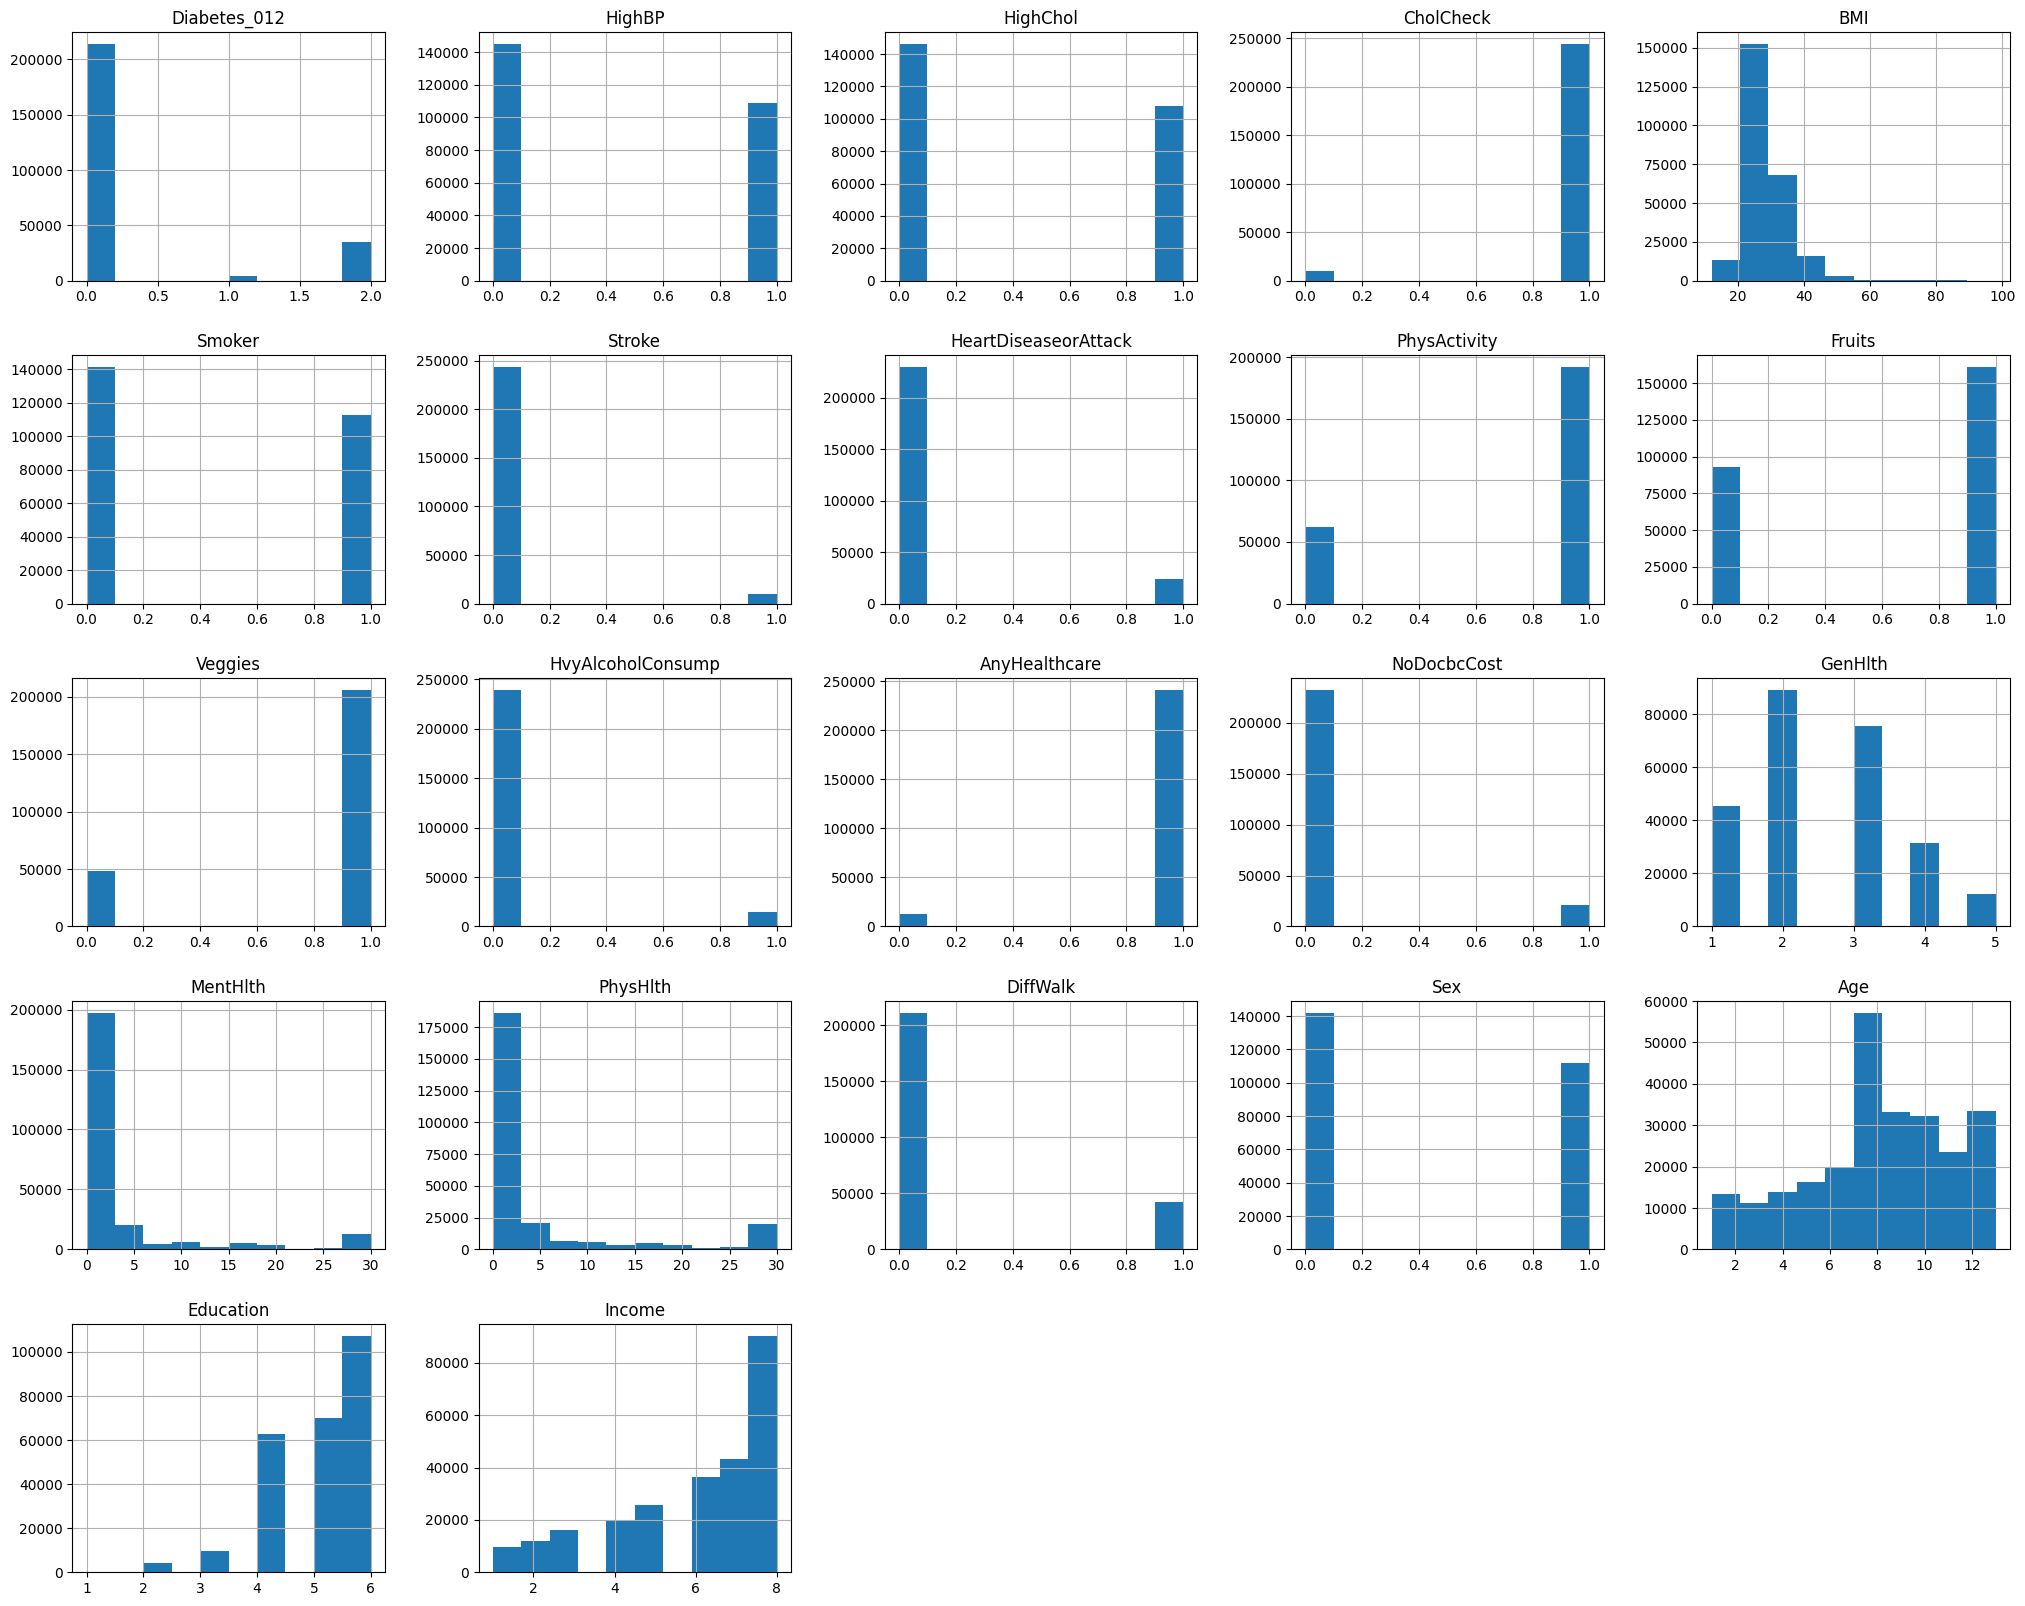

In [8]:
fig = plt.figure(figsize = (25, 20))
ax = fig.gca()
data.hist(ax = ax)

Παρακάτω φαίνονται οι συσχετίσεις των μεταβλητών. Η κλάση (Diabetes_012) δεν έχει μεγάλη συσχέτιση με κάποια συγκεκριμένη στήλη. <br>
Πιθανώς όμως να μπορούμε να βγάλουμε συμπεράσματα από διάφορες μεταβλητές. Η κλάση έχει μικρή συσχέτιση με την υγεία, την υψηλή πίεση, την χολυστερήνη, το BMI και την ηλικία. <br>

<Axes: >

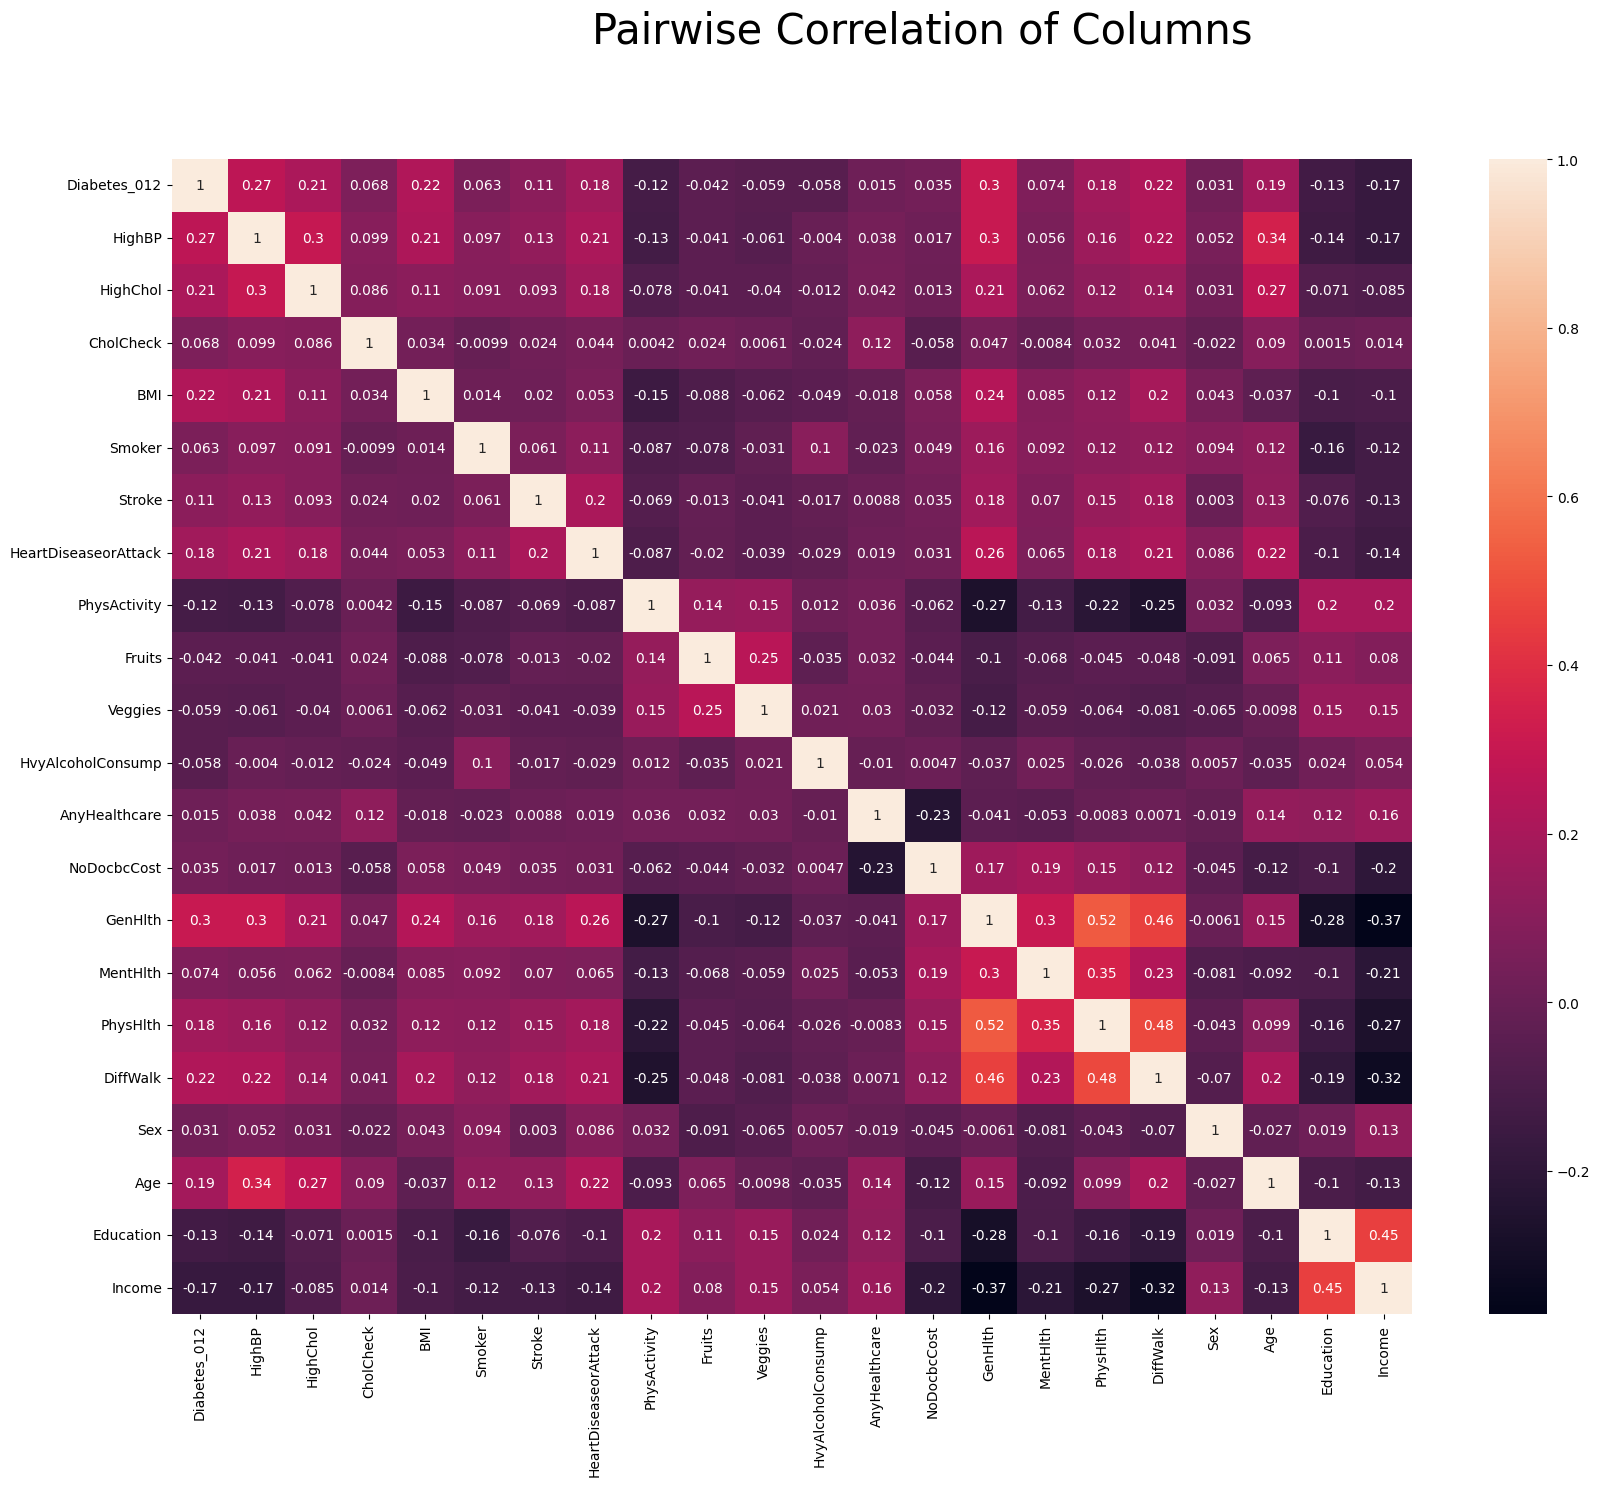

In [9]:
corr_matrix = data.corr()
fig, ax = plt.subplots(figsize=(20,15))
fig.suptitle('Pairwise Correlation of Columns', fontsize=30)
sns.heatmap(corr_matrix, annot=True, ax=ax)

In [10]:
random_state = 42

Spliting the data into training and test set

In [ ]:
from sklearn.model_selection import train_test_split

y = data['Diabetes_012']
x = data.drop(columns=['Diabetes_012'])

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=random_state)

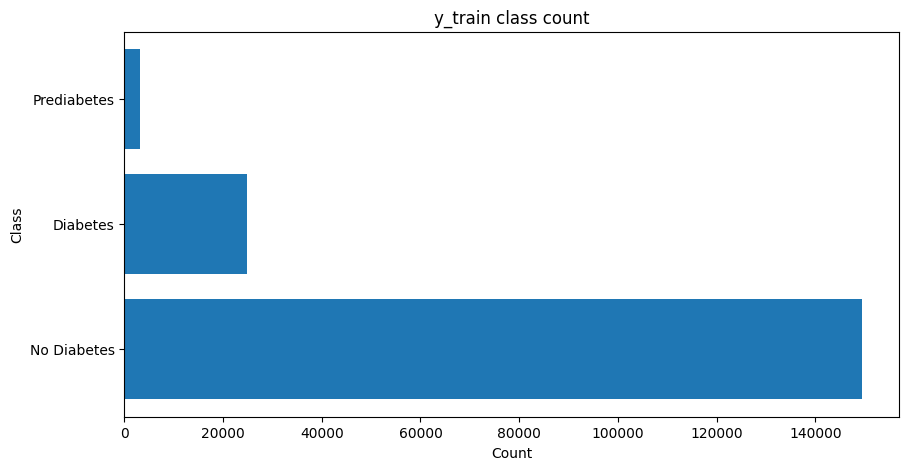

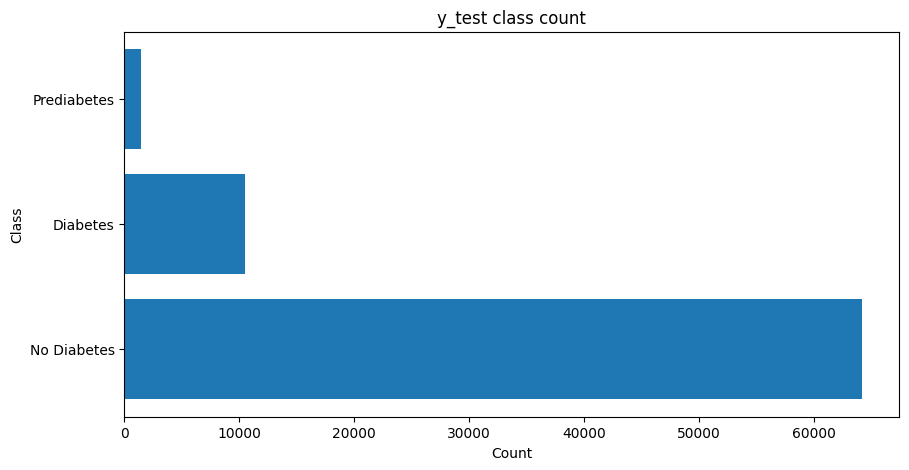

In [12]:
show_class_inbalance(y_train, 'y_train class count')
show_class_inbalance(y_test, 'y_test class count')

##   Παραγωγή Synthetic Data

###  CTGAN

Generating Synthetic Data using CTGAN

In [25]:
from sdv.single_table import CTGANSynthesizer
from sdv.metadata import Metadata

In [ ]:
training_data = pd.concat([x_train, y_train], axis=1)

metadata = Metadata.detect_from_dataframe(training_data)

ctgan_model = CTGANSynthesizer(metadata, epochs=500, verbose=True)
ctgan_model.fit(training_data)
ctgan_model.save(filepath='models/ctgan_model.pkl')


Loading the model

In [22]:
from sdv.utils import load_synthesizer
ctgan_model = load_synthesizer(filepath='models/ctgan_model.pkl')

In [23]:
fig = ctgan_model.get_loss_values_plot()
fig.show()

Lets generate enough data so that all classes have 200.000 data points after the synthetic data is added.

In [47]:
count_no_diabetes = 200000 - int((training_data['Diabetes_012'] == 0).sum())
count_prediabetes = 200000 - int((training_data['Diabetes_012'] == 1).sum())
count_diabetes = 200000 - int((training_data['Diabetes_012'] == 2).sum())

In [49]:
from sdv.sampling import Condition

condition_no_diabetes = Condition(
    num_rows= count_no_diabetes,
    column_values={'Diabetes_012':0}
)

condition_prediabetes = Condition(
    num_rows= count_prediabetes,
    column_values={'Diabetes_012':1}
)

condition_diabetes = Condition(
    num_rows= count_diabetes,
    column_values={'Diabetes_012':2}
)

synthetic_data_ctgan = ctgan_model.sample_from_conditions(
    conditions=[condition_no_diabetes, condition_prediabetes, condition_diabetes]
)

Sampling conditions: 100%|██████████| 422424/422424 [02:03<00:00, 3419.56it/s]


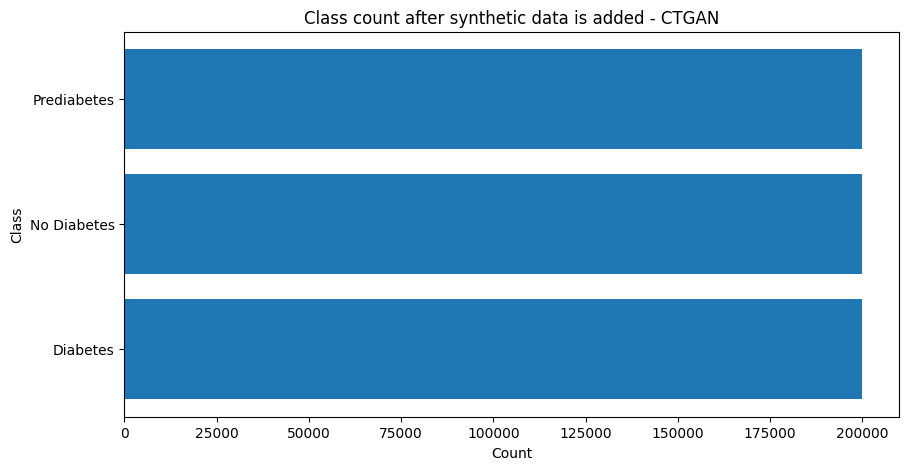

In [55]:
augmented_data_ctgan = pd.concat([training_data, synthetic_data_ctgan])
show_class_inbalance(augmented_data_ctgan, 'Class count after synthetic data is added - CTGAN')

In [58]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

augmented_y_ctgan = data['Diabetes_012']
augmented_x_ctgan = data.drop(columns=['Diabetes_012'])

random_forest_ctgan = RandomForestClassifier()
random_forest_ctgan.fit(augmented_x_ctgan, augmented_y_ctgan)

xgboost_ctgan = XGBClassifier()
xgboost_ctgan.fit(augmented_x_ctgan, augmented_y_ctgan)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [60]:
from sklearn.metrics import classification_report

random_forest_ctgan_pred = random_forest_ctgan.predict(x_test)
xgboost_ctgan_pred = xgboost_ctgan.predict(x_test)

print("Random Forest test scores when trained on augmented data (CTGAN):")
print(classification_report(y_test, random_forest_ctgan_pred))
print("XGBoost test scores when trained on augmented data (CTGAN):")
print(classification_report(y_test, xgboost_ctgan_pred))

Random Forest test scores when trained on augmented data (CTGAN):
              precision    recall  f1-score   support

         0.0       0.99      1.00      1.00     64180
         1.0       1.00      0.93      0.96      1425
         2.0       0.99      0.96      0.98     10499

    accuracy                           0.99     76104
   macro avg       0.99      0.96      0.98     76104
weighted avg       0.99      0.99      0.99     76104

XGBoost test scores when trained on augmented data (CTGAN):
              precision    recall  f1-score   support

         0.0       0.87      0.98      0.92     64180
         1.0       1.00      0.01      0.02      1425
         2.0       0.63      0.22      0.33     10499

    accuracy                           0.86     76104
   macro avg       0.83      0.40      0.42     76104
weighted avg       0.84      0.86      0.82     76104



### SMOTE

### Variational Autoencoder (VAE)

##  Σύγκριση των τεχνικών παραγωγής συνθετικών δεδομένων